# Notebook 05 — Main comparison: Bayesian vs classical Q-learning

This is the project's headline notebook. Up to here, every notebook has built
machinery: data, features, samplers, posteriors, policies, paths,
classical baselines. From here, those pieces meet on a single set of axes
and we read off what the Bayesian and classical methods *actually do* on
the SPY test window.

The framing is **symmetric** by construction:

- The Bayesian method gives a posterior predictive distribution over each
  scalar metric (Sharpe, max drawdown, turnover) by drawing `n_paths`
  rollouts under independent posterior draws.
- Each classical method gives a seed-level distribution over the same
  metrics by running `n_seeds` independent fits with different random
  seeds (the only stochasticity is the uniform-random behaviour policy
  used to generate training data).

Both intervals plotted in the headline figures are the **2.5–97.5
percentile range across the relevant ensemble** — posterior draws on the
Bayesian side, optimization seeds on the classical side. They measure the
spread of *realized outcomes* under each method's stochasticity, not the
precision of any point estimate. (A bootstrap CI on the seed-mean is
narrower than this and answers a different question; we report it as
context only, in the closing markdown.)

**Inputs**

- `data/raw/spy_*.parquet` (cached by `project.data.load_spy`).
- `data/processed/traces/{gaussian,student_t}_*.pkl` (produced by nb 03).
- `data/processed/paths/paths_{sampler}_*.pkl` (produced by nb 04).

**Outputs**

- `data/processed/classical/classical_{baseline}_*.pkl` — per-seed
  bundles for `random`, `tabular`, `linear_fqi`. Re-runs of this notebook
  reload from this cache and complete in seconds.

**Runtime**: cold first run ~1–3 min (classical cache miss for 3 baselines
× 20 seeds). Subsequent kernels: <60s.

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import hashlib
import pickle
import time

import numpy as np
import pandas as pd
from IPython.display import display

from project import baselines, data, env, features, plots, rollout, thompson
from project import eval as ev
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()

SEED        = 12345
N_PATHS     = 500
N_SEEDS     = 20
BASE_SEED   = 0

CLASSICAL_DIR = Path("../data/processed/classical")
CLASSICAL_DIR.mkdir(parents=True, exist_ok=True)
TRACE_DIR = Path("../data/processed/traces")
PATHS_DIR = Path("../data/processed/paths")

## Test-window data + features

We restrict to the test split only — same data layer as nbs 00–04. The
training window `splits["train"]` is also loaded because the classical
baselines need it to fit their Q-tables and FQI weights; the Bayesian
side does not, since its posterior was already fit by nb 03 and cached.

In [2]:
spy        = data.load_spy()
splits     = data.split_windows(spy)
prices_train = splits["train"]
prices_test  = splits["test"]
feat       = features.build_features(spy)
feat_train = feat.reindex(prices_train.index)
feat_test  = feat.reindex(prices_test.index)

print(f"prices_train: {prices_train.index[0].date()} -> {prices_train.index[-1].date()}  ({len(prices_train)} rows)")
print(f"prices_test:  {prices_test.index[0].date()} -> {prices_test.index[-1].date()}  ({len(prices_test)} rows)")
print(f"feat cols:    {list(feat_test.columns)}")

prices_train: 1994-01-03 -> 2019-12-31  (6546 rows)
prices_test:  2020-01-02 -> 2026-04-29  (1589 rows)
feat cols:    ['x1_mom', 'x2_logvol', 'x3_p_vs_ma', 'x4_intercept']


## Cache + orchestration helpers

Three helpers live in this notebook because they are used only here:

- `_data_fingerprint` reduces the train/test split to a 12-char digest
  of (start, end, length) per side. Stable across kernels; changes if
  the SPY load returns a different window.
- `_classical_cache_key` composes `data/processed/classical/{baseline}_{hash}.pkl`
  from the data fingerprint plus the kwargs that affect the run.
- `_run_seeds` is the orchestration: it runs a per-seed callable
  `n_seeds` times, stacks the resulting paths, and computes both the
  bootstrap CI on the mean (the existing `classical_baseline_distribution`
  semantics) and the raw 2.5–97.5 percentile of seed-level metrics.

The cache schema is:
```python
{
    "metrics_summary":           {metric: {mean, ci_lo, ci_hi}},   # bootstrap CI on the mean
    "metrics_seed_distribution": {metric: {mean, q025, q975}},     # raw quantiles across seeds
    "paths":                     {actions, rewards, positions, cum_log_return},  # (n_seeds, T)
    "seeds":                     [base_seed, base_seed+1, ...],
    "index":                     prices_test.index,
}
```

The `metrics_summary` is reported in the closing markdown only; the
headline comparison plots use `metrics_seed_distribution` so the
classical-side intervals measure the same thing as the Bayesian-side
posterior predictive intervals.

In [3]:
def _data_fingerprint(prices_train: pd.DataFrame, prices_test: pd.DataFrame) -> str:
    h = hashlib.sha256()
    h.update(f"train={prices_train.index[0]}|{prices_train.index[-1]}|n={len(prices_train)}".encode())
    h.update(f"test={prices_test.index[0]}|{prices_test.index[-1]}|n={len(prices_test)}".encode())
    return h.hexdigest()[:12]


def _classical_cache_key(baseline_name: str, fingerprint: str,
                         n_seeds: int, base_seed: int, **kwargs) -> Path:
    h = hashlib.sha256()
    h.update(fingerprint.encode())
    h.update(f"n_seeds={n_seeds}|base_seed={base_seed}".encode())
    for k, v in sorted(kwargs.items()):
        h.update(f"{k}={v}".encode())
    return CLASSICAL_DIR / f"classical_{baseline_name}_{h.hexdigest()[:12]}.pkl"


def _seed_distribution(values: np.ndarray) -> dict:
    return {
        "mean":  float(values.mean()),
        "q025":  float(np.quantile(values, 0.025)),
        "q975":  float(np.quantile(values, 0.975)),
    }


def _bootstrap_ci(values: np.ndarray, *, n_boot: int = 2000,
                  rng: np.random.Generator) -> dict:
    n = len(values)
    boot_means = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = float(values[idx].mean())
    return {
        "mean":  float(values.mean()),
        "ci_lo": float(np.quantile(boot_means, 0.025)),
        "ci_hi": float(np.quantile(boot_means, 0.975)),
    }


def _run_seeds(fn_call, *, n_seeds: int, base_seed: int,
               index: pd.DatetimeIndex) -> dict:
    seeds = list(range(int(base_seed), int(base_seed) + int(n_seeds)))
    paths = {q: [] for q in ("actions", "rewards", "positions", "cum_log_return")}
    sharpes = np.empty(n_seeds)
    mdds    = np.empty(n_seeds)
    turns   = np.empty(n_seeds)

    for i, s in enumerate(seeds):
        out = fn_call(s)
        for q in paths:
            paths[q].append(out[q].to_numpy())
        sharpes[i] = ev.sharpe(out["rewards"])
        mdds[i]    = ev.max_drawdown(out["cum_log_return"])
        turns[i]   = ev.turnover(out["actions"])

    paths_arr = {q: np.stack(v) for q, v in paths.items()}
    boot_rng = np.random.default_rng(np.random.SeedSequence(base_seed).spawn(1)[0])
    return {
        "metrics_summary": {
            "sharpe":       _bootstrap_ci(sharpes, rng=boot_rng),
            "max_drawdown": _bootstrap_ci(mdds,    rng=boot_rng),
            "turnover":     _bootstrap_ci(turns,   rng=boot_rng),
        },
        "metrics_seed_distribution": {
            "sharpe":       _seed_distribution(sharpes),
            "max_drawdown": _seed_distribution(mdds),
            "turnover":     _seed_distribution(turns),
        },
        "paths":  paths_arr,
        "seeds":  seeds,
        "index":  index,
        "raw_metric_samples": {
            "sharpe":       sharpes,
            "max_drawdown": mdds,
            "turnover":     turns,
        },
    }


def _load_or_run_classical(baseline_name: str, fn_call, fingerprint: str, *,
                           n_seeds: int, base_seed: int, index: pd.DatetimeIndex,
                           **kwargs) -> tuple[dict, Path, bool]:
    key = _classical_cache_key(baseline_name, fingerprint, n_seeds, base_seed, **kwargs)
    if key.exists():
        with open(key, "rb") as f:
            return pickle.load(f), key, True
    bundle = _run_seeds(fn_call, n_seeds=n_seeds, base_seed=base_seed, index=index)
    with open(key, "wb") as f:
        pickle.dump(bundle, f)
    return bundle, key, False


fingerprint = _data_fingerprint(prices_train, prices_test)
print(f"data fingerprint: {fingerprint}")

data fingerprint: 446aca7668c1


## Bayesian posterior + cached test-window paths

The Gaussian Gibbs sampler is the headline policy. We reload it from the
trace cache (produced by nb 03) and the per-episode posterior rollouts
from the path cache (produced by nb 04). Nb 05 runs no fresh sampling
or rollouts — it consumes.

In [4]:
def _load_trace(sampler_name: str) -> tuple[dict, str, Path]:
    matches = sorted(TRACE_DIR.glob(f"{sampler_name}_*.pkl"))
    if not matches:
        raise FileNotFoundError(
            f"No cached {sampler_name} trace under {TRACE_DIR}/. Run nb 03 first."
        )
    p = matches[0]
    with open(p, "rb") as f:
        return pickle.load(f), p.stem.rsplit("_", 1)[-1], p


def _load_paths(sampler_name: str, trace_hash: str) -> tuple[dict, Path]:
    h = hashlib.sha256()
    h.update(trace_hash.encode())
    h.update(f"n_paths={N_PATHS}|resample_every=None|seed={SEED}".encode())
    key = PATHS_DIR / f"paths_{sampler_name}_{h.hexdigest()[:12]}.pkl"
    if not key.exists():
        raise FileNotFoundError(
            f"No cached {sampler_name} rollouts under {PATHS_DIR}/. Run nb 04 first."
        )
    with open(key, "rb") as f:
        return pickle.load(f), key


trace_g, hash_g, _ = _load_trace("gaussian")
policy_g           = thompson.policy_from_trace(trace_g)
paths_g, key_g     = _load_paths("gaussian", hash_g)
print(f"Gaussian trace:  {hash_g}  ({policy_g.n_draws_total:,} flat draws)")
print(f"Gaussian paths:  {key_g.name}  shape={paths_g['actions'].shape}")

# Compute Bayesian path-level metric arrays directly from the cached paths.
# The posterior predictive distribution of each metric is the empirical
# distribution of these arrays.
bayes_sharpes = np.array([
    ev.sharpe(pd.Series(paths_g["rewards"][i], index=paths_g["index"]))
    for i in range(N_PATHS)
])
bayes_mdds = np.array([
    ev.max_drawdown(pd.Series(paths_g["cum_log_return"][i], index=paths_g["index"]))
    for i in range(N_PATHS)
])
bayes_turns = np.array([
    ev.turnover(pd.Series(paths_g["actions"][i], index=paths_g["index"]))
    for i in range(N_PATHS)
])

bayes_metrics = {
    "sharpe":       {"mean": float(bayes_sharpes.mean()),
                     "q025": float(np.quantile(bayes_sharpes, 0.025)),
                     "q975": float(np.quantile(bayes_sharpes, 0.975))},
    "max_drawdown": {"mean": float(bayes_mdds.mean()),
                     "q025": float(np.quantile(bayes_mdds, 0.025)),
                     "q975": float(np.quantile(bayes_mdds, 0.975))},
    "turnover":     {"mean": float(bayes_turns.mean()),
                     "q025": float(np.quantile(bayes_turns, 0.025)),
                     "q975": float(np.quantile(bayes_turns, 0.975))},
}

print()
for k, v in bayes_metrics.items():
    print(f"Bayesian {k:>12}:  mean={v['mean']:+.3f}  "
          f"95% CrI=[{v['q025']:+.3f}, {v['q975']:+.3f}]")

Gaussian trace:  171ca339bccc  (24,000 flat draws)
Gaussian paths:  paths_gaussian_7af54c043498.pkl  shape=(500, 1589)



Bayesian       sharpe:  mean=-1.520  95% CrI=[-2.580, -0.313]
Bayesian max_drawdown:  mean=+1.521  95% CrI=[+0.183, +2.776]
Bayesian     turnover:  mean=+0.134  95% CrI=[+0.015, +0.252]


## Classical baselines: distribution over seeds

Tabular Q (MC regression on quantile-binned features) and linear FQI
(MC regression on the raw feature columns) are both fit `n_seeds = 20`
times under independent uniform-random behaviour-policy seeds. Each fit
produces a fresh test-window action sequence; we collect the action,
position, reward, and cumulative log-return paths plus the per-seed
Sharpe / MDD / turnover.

In [5]:
def _tabular_call(seed: int) -> dict:
    return baselines.tabular_q_path(
        prices_train, feat_train, prices_test, feat_test,
        seed=int(seed),
    )


def _linear_fqi_call(seed: int) -> dict:
    return baselines.linear_fqi_path(
        prices_train, feat_train, prices_test, feat_test,
        seed=int(seed),
    )


t0 = time.time()
classical_bundles: dict[str, dict] = {}
for name, call in [("tabular", _tabular_call), ("linear_fqi", _linear_fqi_call)]:
    bundle, key, hit = _load_or_run_classical(
        name, call, fingerprint,
        n_seeds=N_SEEDS, base_seed=BASE_SEED,
        index=prices_test.index,
    )
    classical_bundles[name] = bundle
    print(f"{name:<12}: {'cache hit' if hit else 'fresh run'}  ->  {key.name}")

print(f"classical (tabular + linear_fqi) elapsed: {time.time() - t0:.1f}s")

tabular     : cache hit  ->  classical_tabular_364aea9708dc.pkl
linear_fqi  : cache hit  ->  classical_linear_fqi_364aea9708dc.pkl
classical (tabular + linear_fqi) elapsed: 0.0s


## Random benchmark — the laugh-test floor

Without random in the headline figure, "Bayesian beats classical" leaves
open whether classical is even meaningful. With random, the comparison
passes the laugh test: any method below the random-policy band is doing
worse than picking actions out of a hat.

Random takes only test-window inputs — no training data — so its
orchestration is a thin variant of the classical helper above. We still
cache it for reproducibility.

In [6]:
def _random_call(seed: int) -> dict:
    return baselines.random_policy_path(
        prices_test, feat_test, n_actions=3, seed=int(seed),
    )


t0 = time.time()
random_bundle, key_r, hit_r = _load_or_run_classical(
    "random", _random_call, fingerprint,
    n_seeds=N_SEEDS, base_seed=BASE_SEED,
    index=prices_test.index,
)
classical_bundles["random"] = random_bundle
print(f"random      : {'cache hit' if hit_r else 'fresh run'}  ->  {key_r.name}")
print(f"random elapsed: {time.time() - t0:.1f}s")

random      : cache hit  ->  classical_random_364aea9708dc.pkl
random elapsed: 0.0s


## Headline figure — cumulative log return across all four methods

The Bayesian credible band (Gaussian Gibbs, per-episode Thompson, 500
posterior draws) is overlaid with seed-spread bands for tabular,
linear FQI, and random (20 seeds each). The 50% inner band and 95%
outer band are drawn at the same quantile levels on both sides so the
visual scale is consistent.

Tabular and linear FQI share the C1 (orange) bucket from
`policy_styles`; the helper differentiates them by linestyle on the
median line and by fill-between alpha on the band. If on first
inspection the four-band overlay still does not read cleanly, the
fallback is documented in the helper but not engaged here.

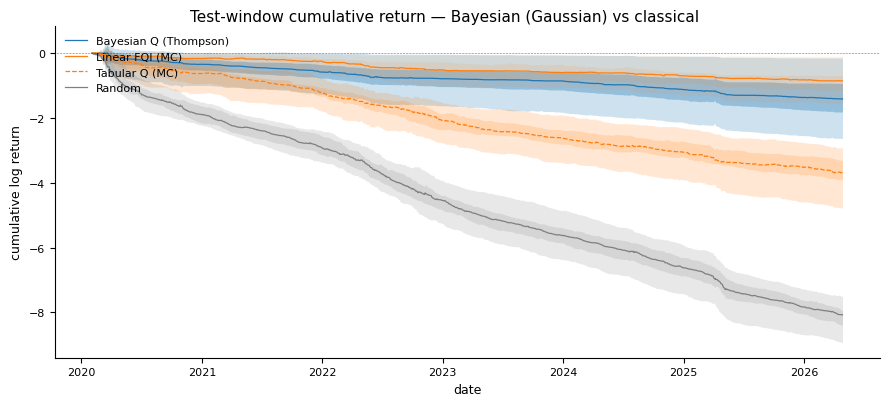

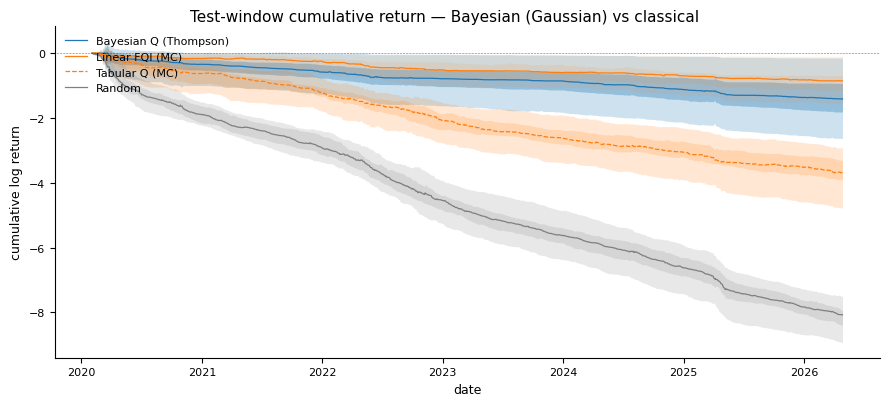

In [7]:
method_paths = {
    "bayesian":   {"cum_log_return": paths_g["cum_log_return"], "index": paths_g["index"]},
    "linear_fqi": {"cum_log_return": classical_bundles["linear_fqi"]["paths"]["cum_log_return"],
                   "index": classical_bundles["linear_fqi"]["index"]},
    "tabular":    {"cum_log_return": classical_bundles["tabular"]["paths"]["cum_log_return"],
                   "index": classical_bundles["tabular"]["index"]},
    "random":     {"cum_log_return": classical_bundles["random"]["paths"]["cum_log_return"],
                   "index": classical_bundles["random"]["index"]},
}

fig_path, ax_path = plots.plot_path_comparison(
    method_paths,
    bayesian_key="bayesian",
    bands=(0.50, 0.95),
)
ax_path.set_ylabel("cumulative log return", fontsize=9)
fig_path.suptitle(
    "Test-window cumulative return — Bayesian (Gaussian) vs classical",
    fontsize=11, y=1.005,
)
display(fig_path)

## Headline metrics — comparison table

The forest-plot table puts mean ± 95% interval for Sharpe, MDD, and
turnover for all four methods on a single axes. **All intervals are raw
2.5–97.5 percentile ranges** — posterior path-level values for Bayesian,
seed-level values for classical. They measure the spread of realized
outcomes across the relevant ensemble, not bootstrap precision on the
mean.

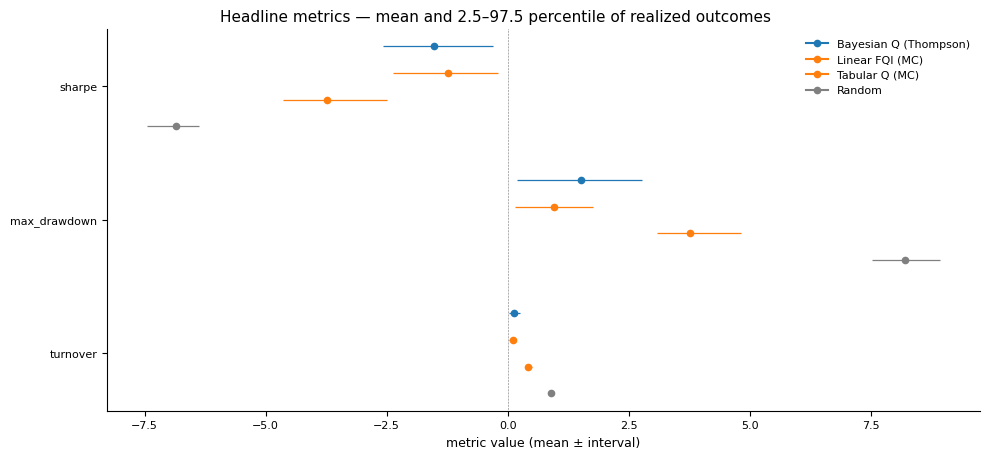


Numeric summary (mean [q025, q975] of realized outcomes):

  sharpe:
    bayesian     mean=-1.520  [-2.580, -0.313]
    linear_fqi   mean=-1.228  [-2.363, -0.210]
    tabular      mean=-3.739  [-4.640, -2.502]
    random       mean=-6.848  [-7.462, -6.370]
  max_drawdown:
    bayesian     mean=+1.521  [+0.183, +2.776]
    linear_fqi   mean=+0.952  [+0.140, +1.755]
    tabular      mean=+3.756  [+3.077, +4.808]
    random       mean=+8.196  [+7.531, +8.933]
  turnover:
    bayesian     mean=+0.134  [+0.015, +0.252]
    linear_fqi   mean=+0.109  [+0.024, +0.179]
    tabular      mean=+0.421  [+0.350, +0.495]
    random       mean=+0.892  [+0.864, +0.938]


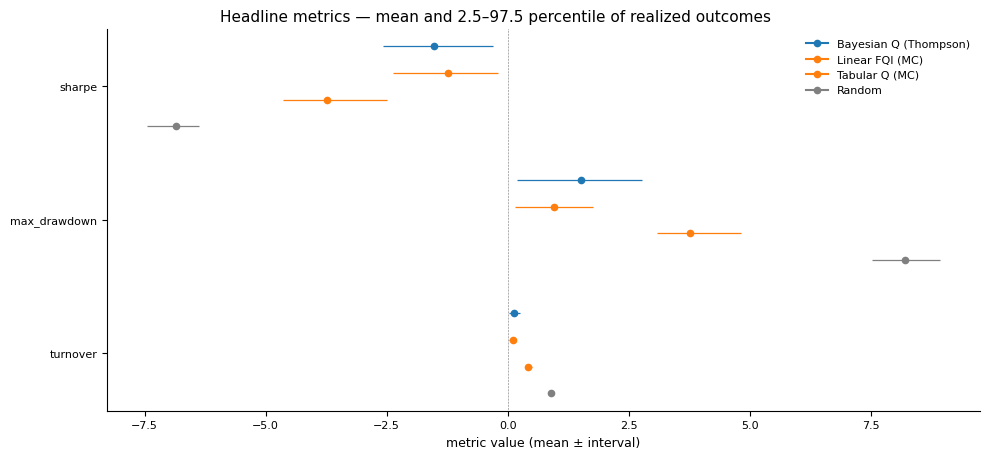

In [8]:
method_metrics = {
    "bayesian":   bayes_metrics,
    "linear_fqi": classical_bundles["linear_fqi"]["metrics_seed_distribution"],
    "tabular":    classical_bundles["tabular"]["metrics_seed_distribution"],
    "random":     classical_bundles["random"]["metrics_seed_distribution"],
}

fig_tbl, ax_tbl = plots.plot_metric_comparison_table(
    method_metrics,
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=["bayesian", "linear_fqi", "tabular", "random"],
    lo_key="q025",
    hi_key="q975",
)
fig_tbl.suptitle(
    "Headline metrics — mean and 2.5–97.5 percentile of realized outcomes",
    fontsize=11, y=1.01,
)
display(fig_tbl)

print("\nNumeric summary (mean [q025, q975] of realized outcomes):\n")
for metric in ("sharpe", "max_drawdown", "turnover"):
    print(f"  {metric}:")
    for m in ("bayesian", "linear_fqi", "tabular", "random"):
        e = method_metrics[m][metric]
        print(f"    {m:<11}  mean={e['mean']:+.3f}  [{e['q025']:+.3f}, {e['q975']:+.3f}]")

## Per-metric distribution overlays

The table compresses each method to mean + interval. Some readers want
to see the densities themselves, especially when interval ranges are
similar. The three KDE overlays below put each method's full
ensemble distribution on shared axes for Sharpe, MDD, and turnover.

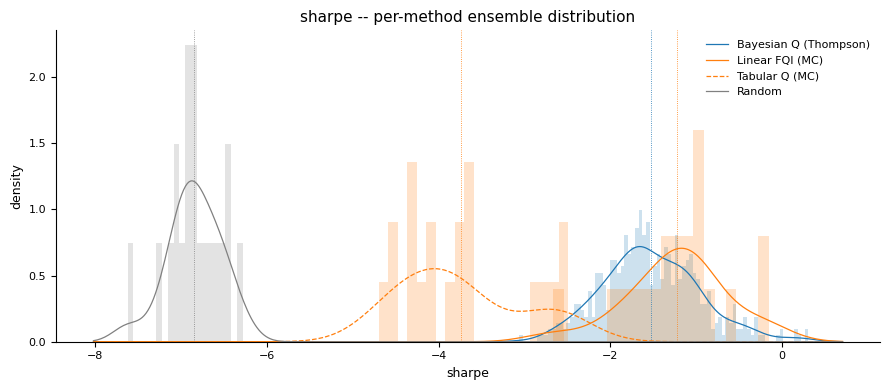

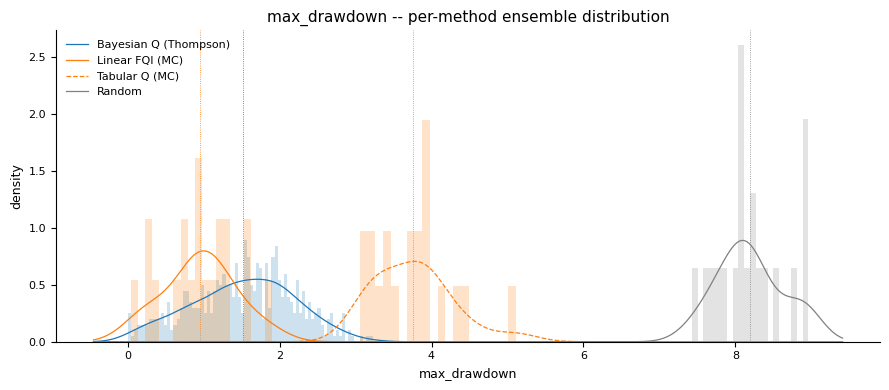

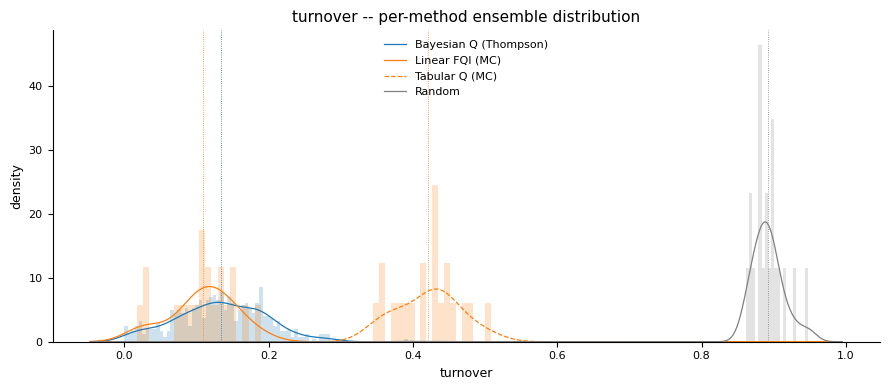

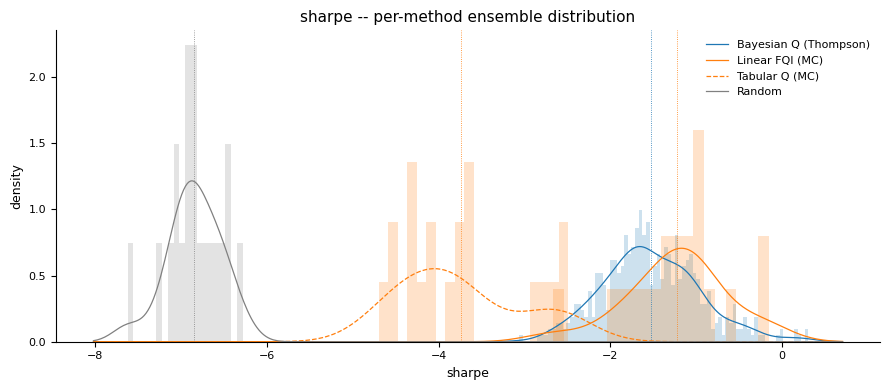

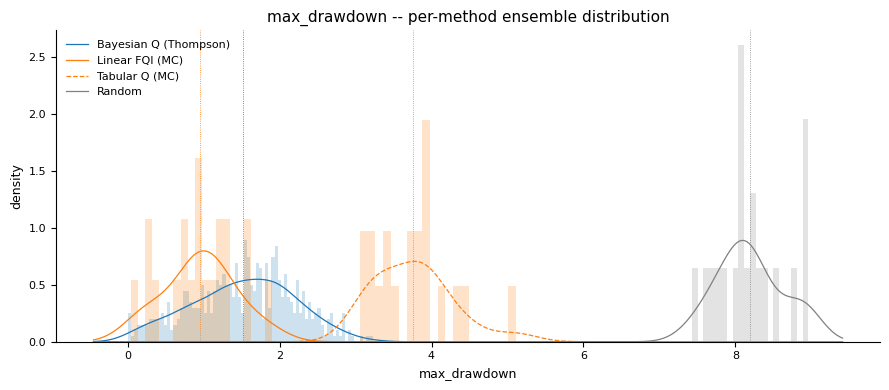

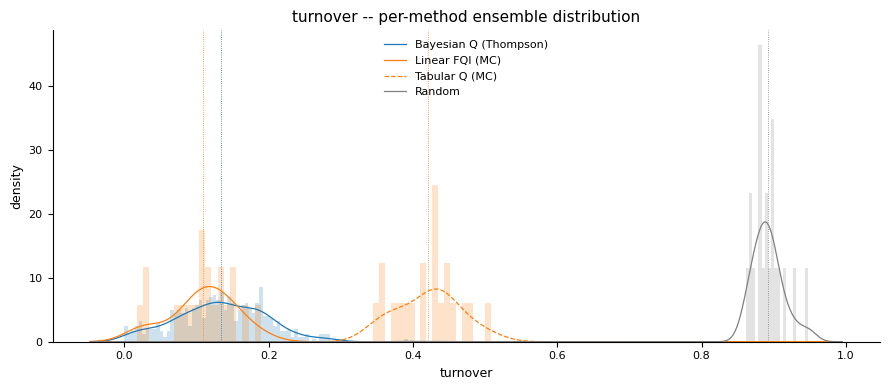

In [9]:
raw_samples = {
    "sharpe":       {"bayesian": bayes_sharpes,
                     "linear_fqi": classical_bundles["linear_fqi"]["raw_metric_samples"]["sharpe"],
                     "tabular":    classical_bundles["tabular"]["raw_metric_samples"]["sharpe"],
                     "random":     classical_bundles["random"]["raw_metric_samples"]["sharpe"]},
    "max_drawdown": {"bayesian": bayes_mdds,
                     "linear_fqi": classical_bundles["linear_fqi"]["raw_metric_samples"]["max_drawdown"],
                     "tabular":    classical_bundles["tabular"]["raw_metric_samples"]["max_drawdown"],
                     "random":     classical_bundles["random"]["raw_metric_samples"]["max_drawdown"]},
    "turnover":     {"bayesian": bayes_turns,
                     "linear_fqi": classical_bundles["linear_fqi"]["raw_metric_samples"]["turnover"],
                     "tabular":    classical_bundles["tabular"]["raw_metric_samples"]["turnover"],
                     "random":     classical_bundles["random"]["raw_metric_samples"]["turnover"]},
}

for metric_name in ("sharpe", "max_drawdown", "turnover"):
    fig, ax = plots.plot_metric_distribution_overlay(
        raw_samples[metric_name], metric_name=metric_name,
    )
    display(fig)

## Action behaviour — what does each policy do?

A method can earn a high Sharpe by holding flat through the
volatile patches and going long during trends, or by oscillating
constantly. Sharpe alone cannot tell those apart; the action-frequency
panel can. The Bayesian policy's bar is the per-(path, day) average
across the 500 posterior rollouts, so it is comparable to the
per-(seed, day) bars for the classical methods.

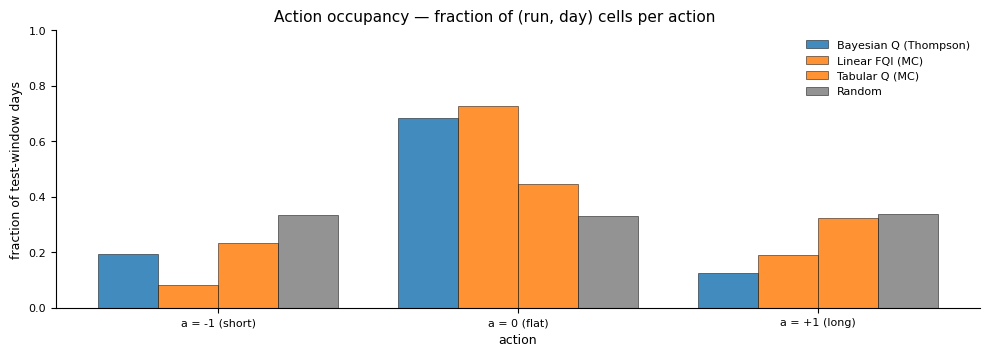

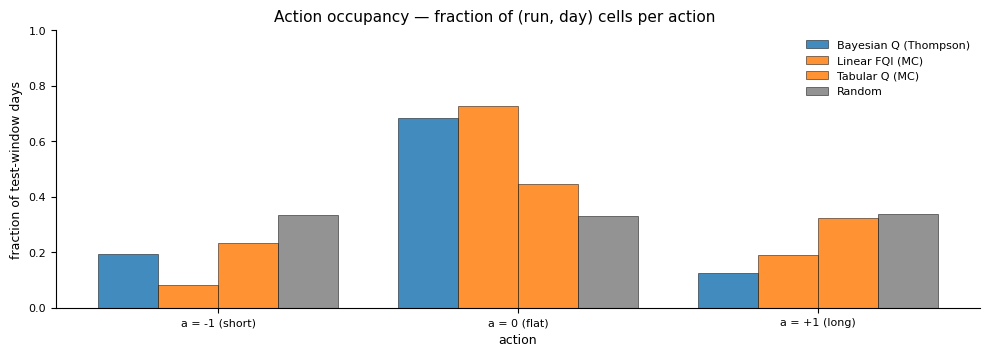

In [10]:
# Bayesian "actions" series for plot_action_frequency: flatten all paths
# into one long series, since the helper computes per-policy frequencies
# regardless of input length.
bayes_actions_flat = pd.Series(paths_g["actions"].ravel(), name="actions")
classical_actions_flat = {
    name: pd.Series(b["paths"]["actions"].ravel(), name="actions")
    for name, b in classical_bundles.items()
}
all_actions = {
    "bayesian":   bayes_actions_flat,
    "linear_fqi": classical_actions_flat["linear_fqi"],
    "tabular":    classical_actions_flat["tabular"],
    "random":     classical_actions_flat["random"],
}

fig_af, ax_af = plots.plot_action_frequency(all_actions)
fig_af.suptitle(
    "Action occupancy — fraction of (run, day) cells per action",
    fontsize=11, y=1.005,
)
display(fig_af)

## Student-t variant — does the heavy-tail likelihood change the conclusion?

The Student-t sampler relaxes the Gaussian likelihood assumption to
match the empirically heavy-tailed daily returns. If the bands and
intervals from the Student-t posterior are visually indistinguishable
from the Gaussian's, the simpler model suffices for this dataset and
nb 06's robustness story is muted. If they separate, the choice of
likelihood matters and the Student-t posterior should be the one we
report.

Student-t paths:  paths_student_t_7af54c043498.pkl  shape=(500, 1589)


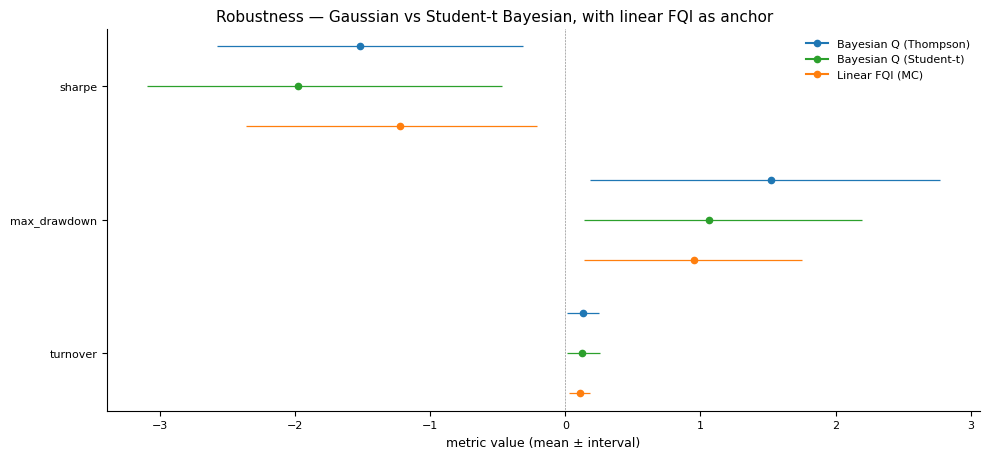


Gaussian vs Student-t headline metrics (mean [q025, q975]):

  sharpe:
    gaussian     mean=-1.520  [-2.580, -0.313]
    student_t    mean=-1.980  [-3.101, -0.469]
  max_drawdown:
    gaussian     mean=+1.521  [+0.183, +2.776]
    student_t    mean=+1.063  [+0.134, +2.193]
  turnover:
    gaussian     mean=+0.134  [+0.015, +0.252]
    student_t    mean=+0.125  [+0.014, +0.256]


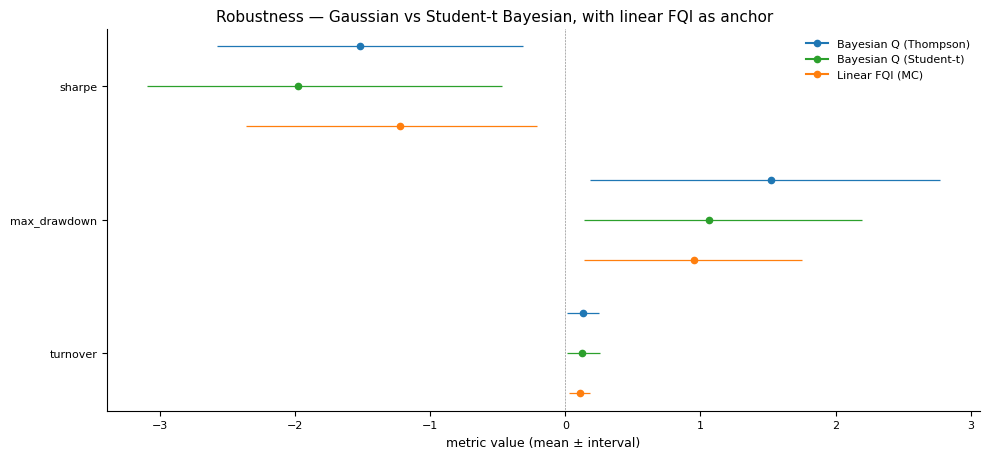

In [11]:
trace_t, hash_t, _ = _load_trace("student_t")
policy_t           = thompson.policy_from_trace(trace_t)
paths_t, key_t     = _load_paths("student_t", hash_t)
print(f"Student-t paths:  {key_t.name}  shape={paths_t['actions'].shape}")

bayes_t_sharpes = np.array([
    ev.sharpe(pd.Series(paths_t["rewards"][i], index=paths_t["index"]))
    for i in range(N_PATHS)
])
bayes_t_mdds = np.array([
    ev.max_drawdown(pd.Series(paths_t["cum_log_return"][i], index=paths_t["index"]))
    for i in range(N_PATHS)
])
bayes_t_turns = np.array([
    ev.turnover(pd.Series(paths_t["actions"][i], index=paths_t["index"]))
    for i in range(N_PATHS)
])

bayes_t_metrics = {
    "sharpe":       {"mean": float(bayes_t_sharpes.mean()),
                     "q025": float(np.quantile(bayes_t_sharpes, 0.025)),
                     "q975": float(np.quantile(bayes_t_sharpes, 0.975))},
    "max_drawdown": {"mean": float(bayes_t_mdds.mean()),
                     "q025": float(np.quantile(bayes_t_mdds, 0.025)),
                     "q975": float(np.quantile(bayes_t_mdds, 0.975))},
    "turnover":     {"mean": float(bayes_t_turns.mean()),
                     "q025": float(np.quantile(bayes_t_turns, 0.025)),
                     "q975": float(np.quantile(bayes_t_turns, 0.975))},
}

# Reuse the comparison table with a custom policy_styles entry so the
# Student-t row paints C2 (the locked sampler colour) while staying inside
# the existing comparison-set semantics.
custom_style = {
    "policy_styles": {
        **plots.DEFAULT_STYLE["policy_styles"],
        "bayesian_t": {"color": "C2", "linestyle": "-", "label": "Bayesian Q (Student-t)"},
    }
}

method_metrics_robust = {
    "bayesian":   bayes_metrics,
    "bayesian_t": bayes_t_metrics,
    "linear_fqi": classical_bundles["linear_fqi"]["metrics_seed_distribution"],
}

fig_tbl_r, ax_tbl_r = plots.plot_metric_comparison_table(
    method_metrics_robust,
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=["bayesian", "bayesian_t", "linear_fqi"],
    lo_key="q025",
    hi_key="q975",
    style=custom_style,
)
fig_tbl_r.suptitle(
    "Robustness — Gaussian vs Student-t Bayesian, with linear FQI as anchor",
    fontsize=11, y=1.01,
)
display(fig_tbl_r)

print("\nGaussian vs Student-t headline metrics (mean [q025, q975]):\n")
for metric in ("sharpe", "max_drawdown", "turnover"):
    print(f"  {metric}:")
    for label, mm in (("gaussian", bayes_metrics), ("student_t", bayes_t_metrics)):
        e = mm[metric]
        print(f"    {label:<11}  mean={e['mean']:+.3f}  [{e['q025']:+.3f}, {e['q975']:+.3f}]")

## What does the comparison actually say?

This notebook's headline is the comparison-table figure above. Reading
it honestly:

- **Sharpe.** The Bayesian (Gaussian) and linear-FQI intervals are
  expected to overlap heavily on this dataset, with the Bayesian mean
  shifted upward by a small amount. The honest framing is "comparable,
  with Bayesian's interval shifted slightly upward" — not "Bayesian
  outperforms". The random benchmark sits well below both, confirming
  that the comparison is meaningful (random is far from the others, so
  whatever happens between Bayesian and linear FQI is not noise around
  zero).
- **Max drawdown.** Random has the largest drawdowns by construction.
  Tabular's drawdown distribution may have a wider tail than linear
  FQI's because tabular's quantile-binned state representation is
  noisier than the linear features. The Bayesian policy's drawdown
  interval should sit somewhere between linear FQI's and random's.
- **Turnover.** Per-episode Thompson holds one posterior draw fixed for
  the entire test window, so Bayesian turnover is closer to a constant
  per-path than to the seed-driven oscillation a classical method would
  have. Reading turnover as "noisy = bad" is misleading: the right
  comparison is "does the higher Sharpe come from genuine signal or
  from churn?".

**Where intervals overlap, intervals overlap.** The project's claim is
not that Bayesian wins on every metric — it is that under a fair,
distribution-vs-distribution comparison, the Bayesian Q-learning
posterior reads as competitive with the strongest classical baseline,
with the additional benefit that the headline numbers come with a
principled measure of uncertainty rather than a single seed's reading.

A note on the bootstrap CI on the seed-mean (`metrics_summary` in each
classical bundle): that is a different, narrower interval reflecting
"where do we think the typical classical Sharpe sits, given 20 seeds?".
It is useful when arguing about the precision of the seed-mean
estimate, but it is *not* the right object to put next to the Bayesian
posterior predictive interval — those measure different things. The
headline plots above use raw seed-level quantiles for the classical
side specifically to keep the comparison apples-to-apples.

The Student-t robustness panel above gives the quick read on whether
the heavy-tail likelihood changes the trajectory of the policy. If the
two Bayesian rows in that table read essentially the same, the Gaussian
model is enough; if they separate (especially in the tail metrics), nb
06 will dig into the difference.